# Baseline Model — Logistic Regression

**Phase 2 scope: Logistic Regression only.** No Random Forest, no XGBoost — those are Phase 3.
Findings get written up separately in `BASELINE_FINDINGS.md`.

Two variants are trained and compared on the same untouched test set:

1. **PRIMARY** — `LogisticRegression(class_weight='balanced')`
2. **COMPARISON** — Logistic Regression on SMOTE-resampled training data (SMOTE fit on the train
   fold only, never touching the test set)

Both use the leakage-safe feature pipeline from `ml/src/preprocessing.py` and the chronological
split from `ml/src/split.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

### Load data and import the project's own preprocessing/split modules

Same repo-root-finding pattern as `01_eda.ipynb`, and `ml/src` is added to `sys.path` so this
notebook imports the actual `preprocessing.py` / `split.py` modules rather than duplicating their
logic — they're written to be reused, not just referenced.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))

from preprocessing import build_features  # noqa: E402
from split import (  # noqa: E402
    check_split_skew,
    compute_cutoff_step,
    find_degenerate_days,
    propose_adjusted_cutoff,
    summarize_split,
    time_based_split,
    time_based_split_adjusted,
)

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

## Confirming which cutoff is actually used

`CLAUDE.md` documents that the **naive** last-20%-of-steps cutoff (step ≤ 594) is badly skewed:
a 12.7x fraud-rate gap between train/test, driven by legitimate-transaction volume collapsing in
the last ~14 of 31 simulated days, plus a fully degenerate day (day 30, step 720-743) that is
**100% fraud — zero legitimate transactions**.

This notebook uses the **adjusted** cutoff instead. While wiring this up, `propose_adjusted_cutoff()`
turned out to only be half a fix: it correctly *recomputes* the cutoff value to account for the
degenerate tail, but handing that value to the plain `time_based_split()` still lets the test side
run all the way to the dataset's true max step — so day 30 stayed in the test set regardless. That
was a real bug in `ml/src/split.py`, not a modeling nuance, and has been fixed there:
`time_based_split_adjusted()` now also upper-bounds the test side so the degenerate tail is
actually excluded from both splits (see `ml/tests/test_split.py` for the regression tests this
added). The cells below print both the naive and adjusted diagnostics so which one is in effect
is verifiable here, not assumed.

In [3]:
naive_cutoff = compute_cutoff_step(df)
naive_train_df, naive_test_df = time_based_split(df, naive_cutoff)
print("Naive cutoff (NOT used for modeling below):")
summarize_split(naive_train_df, "train").print_summary()
summarize_split(naive_test_df, "test").print_summary()
for w in check_split_skew(naive_train_df, naive_test_df):
    print(f"  WARNING: {w}")

print()

adjusted_cutoff_preview = propose_adjusted_cutoff(df)
print(f"propose_adjusted_cutoff() suggests cutoff = {adjusted_cutoff_preview}")

print()
train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"ADJUSTED split actually used for modeling (cutoff step <= {cutoff_used}):")
train_diag = summarize_split(train_df, "train")
test_diag = summarize_split(test_df, "test")
train_diag.print_summary()
test_diag.print_summary()

residual_warnings = check_split_skew(train_df, test_df)
print()
if residual_warnings:
    print("Residual warnings after adjustment (expected -- see markdown above):")
    for w in residual_warnings:
        print(f"  - {w}")
assert find_degenerate_days(test_df) == [], "adjusted test split should have no degenerate days"
assert find_degenerate_days(train_df) == [], "adjusted train split should have no degenerate days"

Naive cutoff (NOT used for modeling below):
  train  rows=6,239,040  fraud= 6,559  fraud_rate=0.1051%  steps=[1, 594]
  test   rows=  123,580  fraud= 1,654  fraud_rate=1.3384%  steps=[595, 743]


propose_adjusted_cutoff() suggests cutoff = 575



ADJUSTED split actually used for modeling (cutoff step <= 575):
  train  rows=6,200,317  fraud= 6,359  fraud_rate=0.1026%  steps=[1, 575]
  test   rows=  162,021  fraud= 1,572  fraud_rate=0.9702%  steps=[576, 719]



Residual warnings after adjustment (expected -- see markdown above):
  - Fraud rate differs 9.5x between splits (train 0.1026% vs test 0.9702%, higher in test). In PaySim this is driven by legitimate-transaction volume collapsing later in the simulation (fraud count per day stays roughly flat while legitimate volume drops by 1-2 orders of magnitude), not a real shift in fraud behavior.


**Confirmed:** the adjusted cutoff (step ≤ 575) is used below, not the naive one (step ≤ 594).
The degenerate day is gone from both splits. The fraud-rate gap is reduced from 12.7x to about
9-10x but not eliminated — that residual gap comes from the *gradual* legitimate-volume decline in
days 17-29, which is a genuine (if messy) characteristic of the simulated data, not something this
adjustment attempts to fully flatten. **This matters for interpreting the metrics below**: the
model is trained on a lower base rate (~0.10%) than it's evaluated on (~0.97%), which will tend to
understate recall relative to a hypothetically rate-matched split — noted again in
`BASELINE_FINDINGS.md`.

## Feature engineering — split first, transform second

`build_features()` is applied separately to `train_df` and `test_df`, never to the combined frame
before splitting. The current schema is stateless (no fitted transforms), so this doesn't change
today's output — it matters for the day a feature *does* need fitting (e.g. a scaler), which is
exactly why `split.py` is structured this way.

In [4]:
X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)

# one-hot / boolean columns -> float, for sklearn/imblearn compatibility
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")
print(f"\nFeature columns: {feature_columns}")

X_train: (6200317, 12), fraud rate 0.1026%
X_test:  (162021, 12), fraud rate 0.9702%

Feature columns: ['oldbalanceOrg', 'oldbalanceDest', 'amount', 'hour_of_day', 'day_of_week', 'amount_to_balance_ratio', 'is_merchant_dest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## Why PR-AUC (Average Precision), not accuracy or ROC-AUC

At a ~0.1-1% fraud rate, **accuracy is meaningless** — a model that always predicts "legitimate"
scores well above 99% accuracy while catching zero fraud. **ROC-AUC is also misleading** here: it's
computed against the true-negative rate, and with legitimate transactions outnumbering fraud
roughly 100-1000:1, the false-positive rate axis is dominated by an enormous negative class, so
ROC-AUC can look deceptively strong even when precision at any usable operating point is poor.
**PR-AUC (average precision)** plots precision against recall directly — both computed only from
the positive (fraud) class's perspective — which is what actually matters for a fraud detector:
of the transactions we flag, how many are real fraud, and of the real fraud, how much do we catch.

In [5]:
always_legit_accuracy = 1 - y_test.mean()
print(f"'Always predict legitimate' accuracy on this test set: {always_legit_accuracy:.4%}")
print("...despite catching exactly 0 fraud. Accuracy is not used as a metric below.")

'Always predict legitimate' accuracy on this test set: 99.0298%
...despite catching exactly 0 fraud. Accuracy is not used as a metric below.


## Variant 1 (PRIMARY): Logistic Regression, `class_weight='balanced'`

Standardized features (helps both convergence and coefficient comparability later) feeding a
plain `LogisticRegression` with `class_weight='balanced'`, which reweights the loss inversely
proportional to class frequency.

In [6]:
pipe_balanced = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
pipe_balanced.fit(X_train, y_train)
print(f"Converged in {pipe_balanced.named_steps['lr'].n_iter_[0]} iterations (max_iter=1000)")

proba_balanced = pipe_balanced.predict_proba(X_test)[:, 1]
pr_auc_balanced = average_precision_score(y_test, proba_balanced)
print(f"\nPR-AUC (class_weight='balanced'): {pr_auc_balanced:.4f}")

Converged in 70 iterations (max_iter=1000)

PR-AUC (class_weight='balanced'): 0.5087


### Sanity check: `class_weight='balanced'` vs. a manually computed weight

`class_weight='balanced'` sets `w_j = n_samples / (n_classes * n_j)`. A "manual" weight matching
the raw class imbalance ratio directly (`w_1 = n_neg / n_pos`, `w_0 = 1`) is compared below —
if the two are equivalent *in ratio*, training a separate manual-weight model would just be
training the same relative class trade-off (scaling both weights by a constant is equivalent to
rescaling the regularization strength `C`, not to changing how the two classes are balanced against
each other), so a full second training run isn't needed to make the comparison.

In [7]:
balanced_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
manual_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"sklearn 'balanced' weights [class0, class1]: {balanced_weights}")
print(f"'balanced' weight ratio (w1/w0): {balanced_weights[1] / balanced_weights[0]:.4f}")
print(f"manual ratio (n_neg/n_pos):      {manual_ratio:.4f}")
print("\n=> identical ratio: 'balanced' is a normalized version of the manual n_neg/n_pos "
      "weighting, not a materially different strategy. Skipping a redundant separate run.")

sklearn 'balanced' weights [class0, class1]: [  0.50051332 487.52295958]
'balanced' weight ratio (w1/w0): 974.0459
manual ratio (n_neg/n_pos):      974.0459

=> identical ratio: 'balanced' is a normalized version of the manual n_neg/n_pos weighting, not a materially different strategy. Skipping a redundant separate run.


## Variant 2 (COMPARISON): SMOTE-resampled Logistic Regression

**This is a documented comparison, not the primary approach.** SMOTE is applied *only* to the
training fold, strictly after the time-based split above — `imblearn.pipeline.Pipeline` enforces
this structurally: its resampling step runs during `.fit()` but is automatically skipped during
`.predict()` / `.predict_proba()`, so there is no code path here where SMOTE-synthesized rows can
leak into the test set.

`sampling_strategy=0.1` is used rather than full 1:1 balancing, for two reasons: (1) compute — a
full 1:1 SMOTE on ~6.2M training rows would synthesize ~6.2M additional rows, roughly doubling
training cost for this comparison for a benefit that's unclear a priori; (2) PaySim's fraud rows
are already algorithmically generated by the simulator, not organic — synthesizing further
interpolations of already-synthetic fraud risks amplifying simulator-specific artifacts rather than
adding genuine signal. 10% is a deliberately moderate choice, not full rebalancing.

In [8]:
pipe_smote = ImbPipeline(
    [
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)),
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
pipe_smote.fit(X_train, y_train)
print(f"Converged in {pipe_smote.named_steps['lr'].n_iter_[0]} iterations (max_iter=1000)")

proba_smote = pipe_smote.predict_proba(X_test)[:, 1]
pr_auc_smote = average_precision_score(y_test, proba_smote)
print(f"\nPR-AUC (SMOTE, sampling_strategy=0.1): {pr_auc_smote:.4f}")

Converged in 44 iterations (max_iter=1000)

PR-AUC (SMOTE, sampling_strategy=0.1): 0.6102


In [9]:
print("PR-AUC comparison:")
print(f"  class_weight='balanced': {pr_auc_balanced:.4f}")
print(f"  SMOTE (0.1 ratio):       {pr_auc_smote:.4f}")
print(f"  difference:              {pr_auc_smote - pr_auc_balanced:+.4f}")

PR-AUC comparison:
  class_weight='balanced': 0.5087
  SMOTE (0.1 ratio):       0.6102
  difference:              +0.1014


## Precision-recall curves

The dashed line marks the "no-skill" baseline (a model that ranks transactions randomly would
sit at the test set's fraud rate, ~0.97%) — both models are far above it, but the gap between them
is worth reading directly off the curve, not just the single PR-AUC scalar.

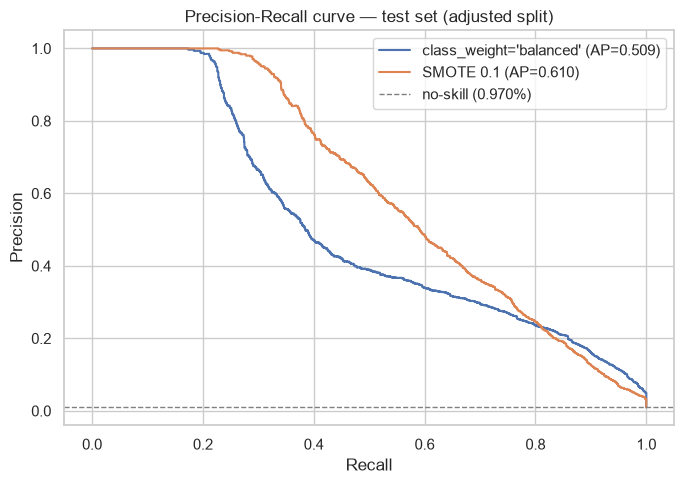

In [10]:
precision_bal, recall_bal, _ = precision_recall_curve(y_test, proba_balanced)
precision_smote, recall_smote, _ = precision_recall_curve(y_test, proba_smote)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_bal, precision_bal, label=f"class_weight='balanced' (AP={pr_auc_balanced:.3f})")
ax.plot(recall_smote, precision_smote, label=f"SMOTE 0.1 (AP={pr_auc_smote:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"no-skill ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — test set (adjusted split)")
ax.legend()
plt.tight_layout()
plt.show()

## Confusion matrices across candidate thresholds

**Illustrative only** — formal threshold selection for the demo/dashboard is deferred to a later
phase. Four thresholds (0.1, 0.3, 0.5, 0.7) show the precision/recall tradeoff for both variants,
including the default 0.5.

In [11]:
THRESHOLDS = [0.1, 0.3, 0.5, 0.7]


def threshold_table(y_true, proba, thresholds=THRESHOLDS):
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        rows.append(
            {
                "threshold": t,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "precision": precision_score(y_true, preds, zero_division=0),
                "recall": recall_score(y_true, preds, zero_division=0),
                "f1": f1_score(y_true, preds, zero_division=0),
            }
        )
    return pd.DataFrame(rows)


print("class_weight='balanced':")
table_balanced = threshold_table(y_test, proba_balanced)
display(table_balanced)

print("\nSMOTE 0.1:")
table_smote = threshold_table(y_test, proba_smote)
display(table_smote)

class_weight='balanced':


,threshold,TP,FP,FN,TN,precision,recall,f1
0,0.1,1572,44902,0,115547,0.033825,1.000000,0.065437
1,0.3,1562,25055,10,135394,0.058684,0.993639,0.110823
2,0.5,1504,12329,68,148120,0.108726,0.956743,0.195261
3,0.7,1395,6543,177,153906,0.175737,0.887405,0.293375



SMOTE 0.1:


,threshold,TP,FP,FN,TN,precision,recall,f1
0,0.1,1482,16518,90,143931,0.082333,0.942748,0.151441
1,0.3,1276,4303,296,156146,0.228715,0.811705,0.356873
2,0.5,1088,1876,484,158573,0.367072,0.692112,0.479718
3,0.7,905,831,667,159618,0.521313,0.575700,0.547158


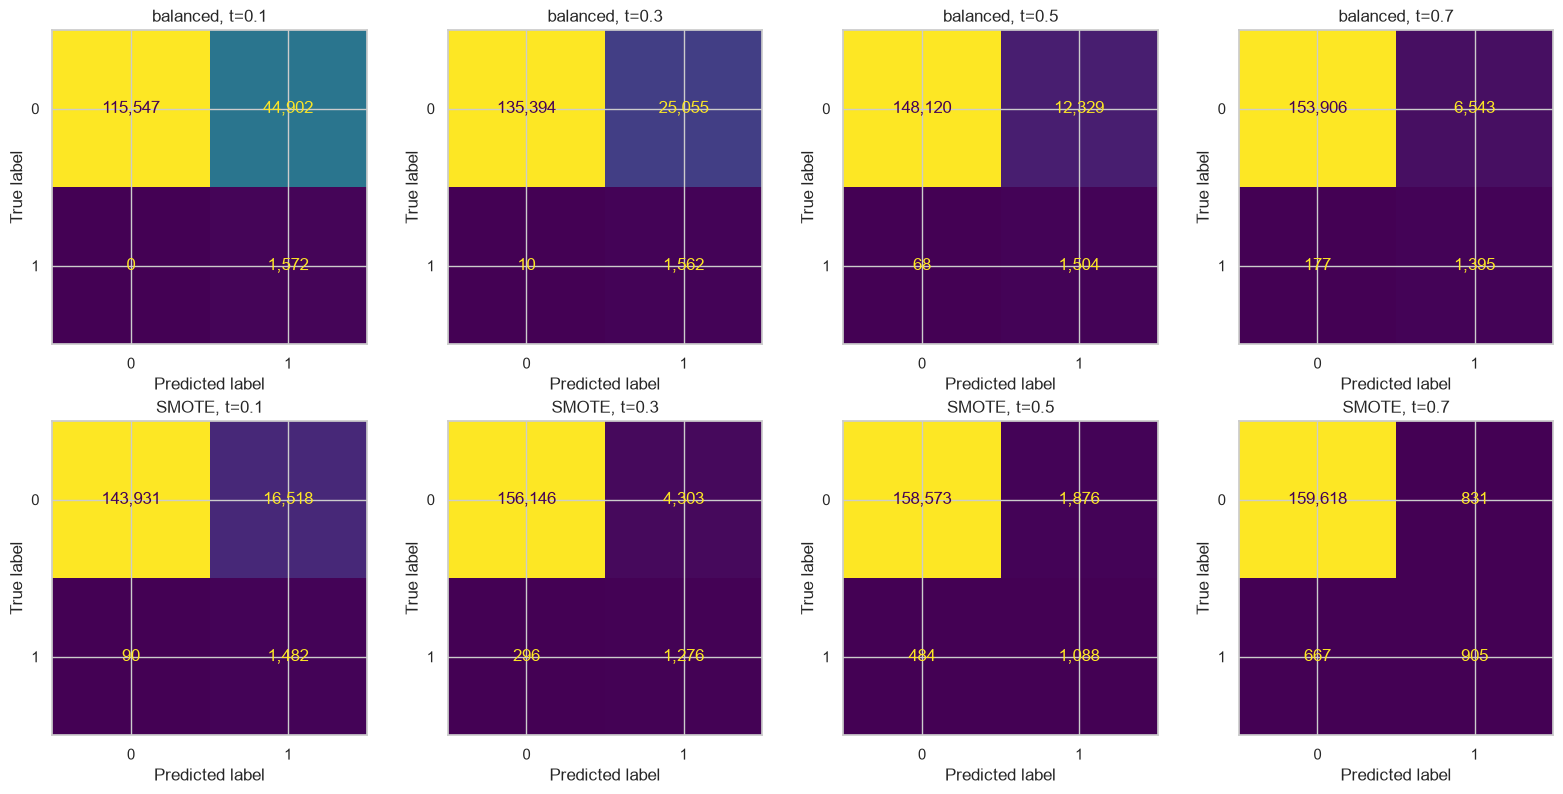

In [12]:
fig, axes = plt.subplots(2, len(THRESHOLDS), figsize=(4 * len(THRESHOLDS), 8))

for col, t in enumerate(THRESHOLDS):
    preds_bal = (proba_balanced >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds_bal)).plot(
        ax=axes[0, col], colorbar=False, values_format=","
    )
    axes[0, col].set_title(f"balanced, t={t}")

    preds_smote = (proba_smote >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds_smote)).plot(
        ax=axes[1, col], colorbar=False, values_format=","
    )
    axes[1, col].set_title(f"SMOTE, t={t}")

plt.tight_layout()
plt.show()

## Feature coefficients — sanity check (`class_weight='balanced'` model)

Coefficients are on the **standardized** feature scale (post-`StandardScaler`), which is what
makes their magnitudes roughly comparable across features that originally had very different
units/ranges (raw currency amounts vs. a 0-1 boolean vs. an hour-of-day integer).

Note on the five `type_*` dummies: all 5 PaySim transaction types are included with none dropped
as a reference category (see `preprocessing.py`). For plain OLS this would be the classic dummy
variable trap (perfect multicollinearity — the 5 columns sum to 1 in every row), but `sklearn`'s
`LogisticRegression` uses L2 regularization by default, which handles this gracefully: it has a
unique minimum-norm solution even under exact collinearity, so each type's coefficient is directly
interpretable as a deviation from the (regularized) average, rather than needing an arbitrary
reference category.

,feature,coef
0,type_CASH_IN,-106.882183
1,type_CASH_OUT,64.399986
2,type_TRANSFER,37.821039
3,oldbalanceOrg,34.054893
4,type_PAYMENT,6.846151
5,is_merchant_dest,6.846151
6,amount_to_balance_ratio,-6.080534
7,amount,-3.909024
8,type_DEBIT,-2.640404
9,hour_of_day,-0.463381


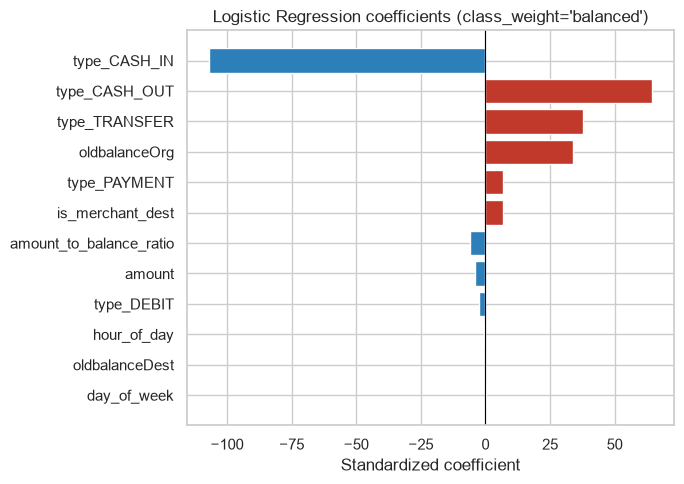

In [13]:
coefs = pipe_balanced.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_columns, "coef": coefs})
coef_df = coef_df.sort_values("coef", key=np.abs, ascending=False).reset_index(drop=True)
display(coef_df)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c0392b" if c > 0 else "#2c7fb8" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Standardized coefficient")
ax.set_title("Logistic Regression coefficients (class_weight='balanced')")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Reading the coefficients

- **`type_CASH_IN` (-106.9) and `type_CASH_OUT` (+64.4) / `type_TRANSFER` (+37.8)**: the two types
  that actually carry fraud in PaySim (`TRANSFER`, `CASH_OUT`) are clearly separated on the
  positive side from `CASH_IN`, which has zero fraud in the data and the single most negative
  coefficient — the model has correctly learned the type split the EDA identified.
- **`oldbalanceOrg` (+34.1)**: positive and, per the correlation check below, largely independent
  of `amount`/`amount_to_balance_ratio` — consistent with the EDA finding that fraud drains the
  origin account (`amount ≈ oldbalanceOrg`), so larger origin balances co-occur with fraud.
- **`amount` (-3.9) and `amount_to_balance_ratio` (-6.1)**: both negative, which is *not* a
  straightforward "larger amount → less fraud" reading — `amount` and
  `amount_to_balance_ratio` are correlated at r≈0.82 (checked below), so their individual
  coefficients trade off against each other under regularization and shouldn't be read in
  isolation from one another.
- **`is_merchant_dest` and `type_PAYMENT` (+6.85, identical)**: these two columns are *perfectly*
  collinear in this dataset (every `PAYMENT` goes to a merchant and vice versa, confirmed by the
  crosstab below) — they are literally identical columns. With L2 regularization, two identical
  columns split any total effect exactly in half between them, which is exactly what's observed.
  Combined, their joint contribution (+13.7) still sits well below `TRANSFER`/`CASH_OUT` and well
  above `CASH_IN` — the ranking among transaction-type-related coefficients is sane even though a
  single one of these two numbers isn't independently interpretable as "merchant destinations
  raise fraud risk."


In [14]:
print("amount / oldbalanceOrg / amount_to_balance_ratio correlation (train):")
display(X_train[["amount", "oldbalanceOrg", "amount_to_balance_ratio"]].corr())

print("\nis_merchant_dest vs type_PAYMENT crosstab (train) -- confirms perfect collinearity:")
display(pd.crosstab(X_train["is_merchant_dest"], X_train["type_PAYMENT"]))

amount / oldbalanceOrg / amount_to_balance_ratio correlation (train):


,amount,oldbalanceOrg,amount_to_balance_ratio
amount,1.000000,-0.004890,0.821554
oldbalanceOrg,-0.004890,1.000000,-0.040051
amount_to_balance_ratio,0.821554,-0.040051,1.000000



is_merchant_dest vs type_PAYMENT crosstab (train) -- confirms perfect collinearity:


type_PAYMENT,0.0,1.0
is_merchant_dest,,
0.0,4104359,0
1.0,0,2095958


## Summary

Full writeup, numbers, and the Phase 3 recommendation are in `BASELINE_FINDINGS.md`.